## Temporal & Macroeconomic Analysis

In [56]:
sns.set_style("white")
pastel_green = '#2d8659'
pastel_purple = '#c8b6e2'

In [57]:
# The dataset is sorted by date (May 2008 → Nov 2010). Each (month + euribor3m)
# combination uniquely identifies a year because the euribor rate dropped
# steadily over the campaign period.

# Strategy: order rows by their original index (which preserves chronology),
# then walk through months and assign years based on calendar logic.

month_to_num = {'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6,
                'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12}

df_clean['month_num'] = df_clean['month'].map(month_to_num)

# Walk through rows and increment year whenever the month sequence resets
years = []
current_year = 2008
prev_month = None

for m in df_clean['month_num']:
    if prev_month is not None and m < prev_month:
        current_year += 1
    years.append(current_year)
    prev_month = m

df_clean['year'] = years

# Build a year-month label for plotting
df_clean['year_month'] = df_clean['year'].astype(str) + '-' + df_clean['month_num'].astype(str).str.zfill(2)

# Verify reconstruction by checking euribor by year
print("YEAR RECONSTRUCTION SANITY CHECK")
print("\nMean euribor3m by reconstructed year (should decrease over time):")
print(df_clean.groupby('year')['euribor3m'].mean().round(2))

print("\nRow counts by year:")
print(df_clean['year'].value_counts().sort_index())

print("\nUnique month-year combinations:")
print(df_clean.groupby(['year', 'month_num']).size().reset_index(name='calls').to_string(index=False))

YEAR RECONSTRUCTION SANITY CHECK

Mean euribor3m by reconstructed year (should decrease over time):
year
2008    4.82
2009    1.23
2010    0.81
Name: euribor3m, dtype: float64

Row counts by year:
year
2008    27682
2009    11436
2010     2058
Name: count, dtype: int64

Unique month-year combinations:
 year  month_num  calls
 2008          5   7762
 2008          6   4374
 2008          7   6681
 2008          8   5173
 2008         10     67
 2008         11   3615
 2008         12     10
 2009          3    282
 2009          4   2457
 2009          5   5793
 2009          6    715
 2009          7    177
 2009          8    770
 2009          9    267
 2009         10    446
 2009         11    357
 2009         12    172
 2010          3    264
 2010          4    174
 2010          5    212
 2010          6    229
 2010          7    311
 2010          8    233
 2010          9    303
 2010         10    204
 2010         11    128


In [58]:
# CONVERSION RATE OVER TIME

timeline = df_clean.groupby('year_month').agg(
    calls=('y_binary', 'count'),
    subscribers=('y_binary', 'sum'),
    conv_rate=('y_binary', 'mean'),
    euribor=('euribor3m', 'mean'),
    emp_var=('emp.var.rate', 'mean'),
    nr_emp=('nr.employed', 'mean'),
    cons_conf=('cons.conf.idx', 'mean')
).reset_index()
timeline['conv_rate_pct'] = (timeline['conv_rate'] * 100).round(2)
timeline = timeline.sort_values('year_month').reset_index(drop=True)

print("CONVERSION RATE BY MONTH (FULL TIMELINE)")
print(timeline[['year_month', 'calls', 'subscribers', 'conv_rate_pct', 'euribor']].to_string(index=False))

CONVERSION RATE BY MONTH (FULL TIMELINE)
year_month  calls  subscribers  conv_rate_pct  euribor
   2008-05   7762          240           3.09 4.857663
   2008-06   4374          188           4.30 4.931639
   2008-07   6681          407           6.09 4.961585
   2008-08   5173          271           5.24 4.964804
   2008-10     67           42          62.69 4.923776
   2008-11   3615          190           5.26 4.114884
   2008-12     10            1          10.00 3.493400
   2009-03    282          126          44.68 1.646220
   2009-04   2457          442          17.99 1.411717
   2009-05   5793          524           9.05 1.293568
   2009-06    715          264          36.92 1.257890
   2009-07    177           65          36.72 1.024955
   2009-08    770          264          34.29 0.866087
   2009-09    267          106          39.70 0.783052
   2009-10    446          180          40.36 0.735482
   2009-11    357          168          47.06 0.716143
   2009-12    172       

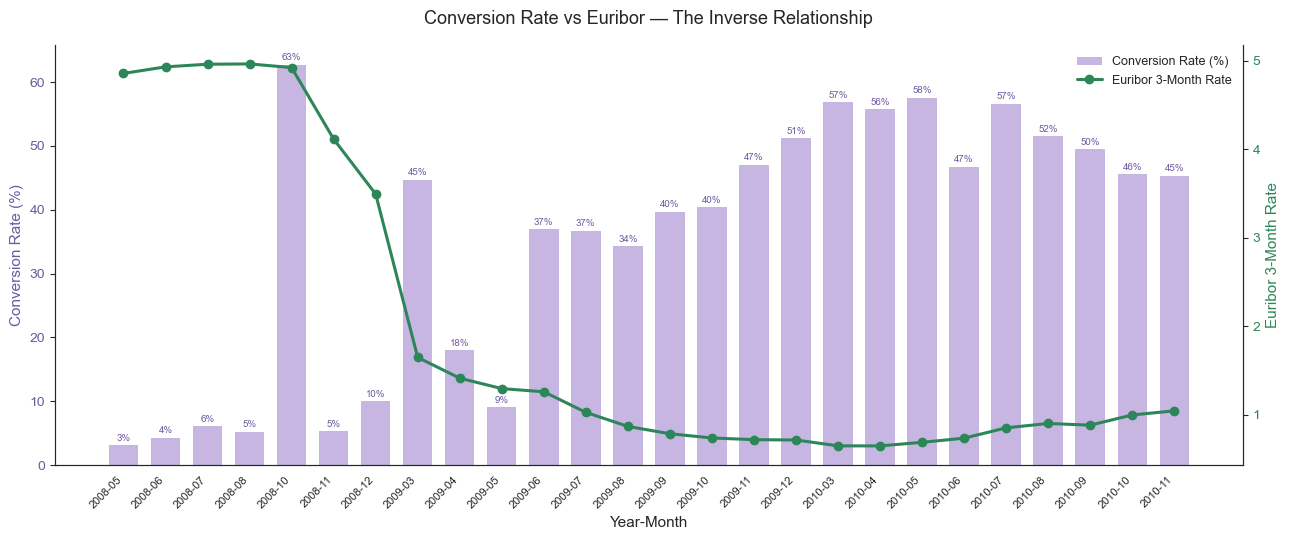

In [59]:
# EURIBOR vs CONVERSION RATE — THE CENTERPIECE

fig, ax1 = plt.subplots(figsize=(13, 5.5))

x = range(len(timeline))

# Bar chart: conversion rate
bars = ax1.bar(x, timeline['conv_rate_pct'], color=pastel_purple,
               edgecolor='none', label='Conversion Rate (%)', width=0.7)
ax1.set_xlabel('Year-Month', fontsize=11)
ax1.set_ylabel('Conversion Rate (%)', fontsize=11, color='#6d5aa0')
ax1.tick_params(axis='y', labelcolor='#6d5aa0')
ax1.set_xticks(x)
ax1.set_xticklabels(timeline['year_month'], rotation=45, ha='right', fontsize=8)

# Conversion rate labels on bars
for i, v in enumerate(timeline['conv_rate_pct']):
    ax1.text(i, v + 0.7, f'{v:.0f}%', ha='center', fontsize=7, color='#6d5aa0')

# Line chart: euribor (secondary axis)
ax2 = ax1.twinx()
ax2.plot(x, timeline['euribor'], color=pastel_green,
         marker='o', markersize=6, linewidth=2.2, label='Euribor 3-Month Rate')
ax2.set_ylabel('Euribor 3-Month Rate', fontsize=11, color=pastel_green)
ax2.tick_params(axis='y', labelcolor=pastel_green)

plt.title('Conversion Rate vs Euribor — The Inverse Relationship',
          fontsize=13, pad=15)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper right', frameon=False, fontsize=9)

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

YEAR-OVER-YEAR PERFORMANCE
 year  calls  subscribers  conv_rate_pct  avg_euribor
 2008  27682         1339           4.84         4.82
 2009  11436         2227          19.47         1.23
 2010   2058         1073          52.14         0.81


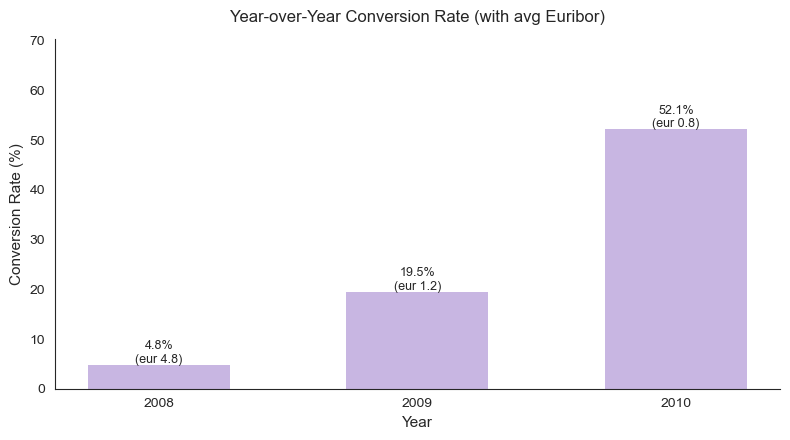

In [60]:
# CONVERSION RATE BY YEAR

yearly = df_clean.groupby('year').agg(
    calls=('y_binary', 'count'),
    subscribers=('y_binary', 'sum'),
    conv_rate=('y_binary', 'mean'),
    avg_euribor=('euribor3m', 'mean')
).reset_index()
yearly['conv_rate_pct'] = (yearly['conv_rate'] * 100).round(2)
yearly['avg_euribor'] = yearly['avg_euribor'].round(2)

print("YEAR-OVER-YEAR PERFORMANCE")
print(yearly[['year', 'calls', 'subscribers', 'conv_rate_pct', 'avg_euribor']].to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(yearly['year'].astype(str), yearly['conv_rate_pct'],
              color=pastel_purple, edgecolor='none', width=0.55)
for bar, val, eur in zip(bars, yearly['conv_rate_pct'], yearly['avg_euribor']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.4,
            f'{val:.1f}%\n(eur {eur:.1f})', ha='center', fontsize=9)
ax.set_ylabel('Conversion Rate (%)', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.set_title('Year-over-Year Conversion Rate (with avg Euribor)', fontsize=12, pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(yearly['conv_rate_pct']) * 1.35)
plt.tight_layout()
plt.show()

In [61]:
# ECONOMIC PHASE BREAKDOWN

# Bucket the timeline into economic phases based on euribor levels
def assign_phase(row):
    if row['euribor3m'] >= 4.0:
        return '1_high_rate (crisis peak)'
    elif row['euribor3m'] >= 1.5:
        return '2_falling_rate (transition)'
    else:
        return '3_low_rate (recovery)'

df_clean['economic_phase'] = df_clean.apply(assign_phase, axis=1)

phase_stats = df_clean.groupby('economic_phase').agg(
    calls=('y_binary', 'count'),
    subscribers=('y_binary', 'sum'),
    conv_rate=('y_binary', 'mean'),
    avg_euribor=('euribor3m', 'mean')
).reset_index()
phase_stats['conv_rate_pct'] = (phase_stats['conv_rate'] * 100).round(2)
phase_stats['call_share_pct'] = (phase_stats['calls'] / len(df_clean) * 100).round(2)
phase_stats['lift'] = (phase_stats['conv_rate_pct'] /
                        (df_clean['y_binary'].mean() * 100)).round(2)

print("PERFORMANCE BY ECONOMIC PHASE")
print(phase_stats[['economic_phase', 'calls', 'call_share_pct',
                   'subscribers', 'conv_rate_pct', 'avg_euribor', 'lift']].to_string(index=False))

PERFORMANCE BY ECONOMIC PHASE
             economic_phase  calls  call_share_pct  subscribers  conv_rate_pct  avg_euribor  lift
  1_high_rate (crisis peak)  27668           67.19         1338           4.84     4.817737  0.43
2_falling_rate (transition)    296            0.72          127          42.91     1.738784  3.81
      3_low_rate (recovery)  13212           32.09         3174          24.02     1.157929  2.13


CONVERSION RATE BY MONTH × YEAR


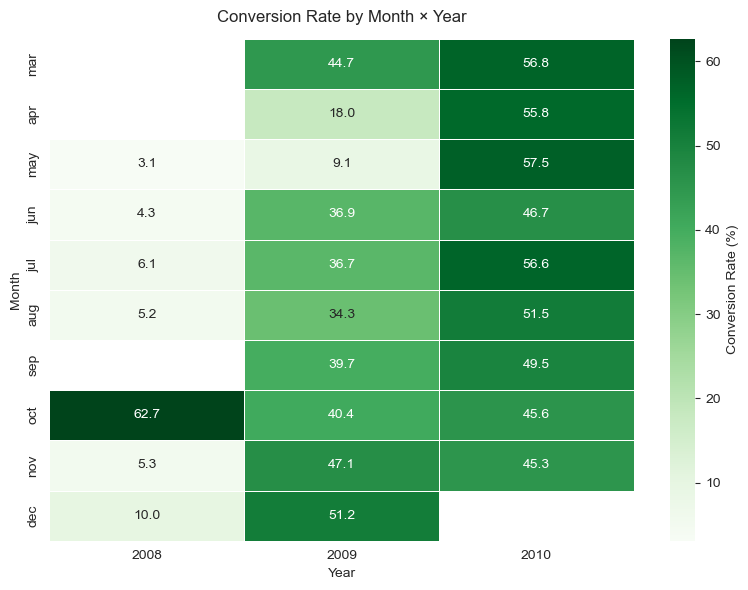

In [62]:
# MONTH EFFECT BY YEAR

# For each month, show conversion rate by year — does the same month
# perform consistently, or does it depend on the year?
month_year = df_clean.pivot_table(
    index='month',
    columns='year',
    values='y_binary',
    aggfunc='mean'
) * 100

month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_year = month_year.reindex(month_order).round(2)

print("CONVERSION RATE BY MONTH × YEAR")

# Heatmap visualization
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(month_year, annot=True, fmt='.1f', cmap='Greens',
            cbar_kws={'label': 'Conversion Rate (%)'}, linewidths=0.5,
            annot_kws={'fontsize': 10}, ax=ax)
ax.set_title('Conversion Rate by Month × Year', fontsize=12, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Month')
plt.tight_layout()
plt.show()

#### The Big Reframe:

Steps 1-4 treated the dataset as ahistorical — patterns by month, channel, segment. Step 5 reveals that the data spans the **2008 global financial crisis and recovery**, and that economic context is the dominant driver of conversion behavior. Several earlier conclusions need to be reframed in light of this.

#### Year-Over-Year Performance:

Conversion rate increased more than **10x** from 2008 to 2010, while euribor 3-month rates fell from 4.82 to 0.81:

| Year | Calls | Subscribers | Conversion | Avg Euribor |
|------|------:|------------:|-----------:|------------:|
| 2008 | 27,682 | 1,339 | **4.84%** | 4.82 |
| 2009 | 11,436 | 2,227 | **19.47%** | 1.23 |
| 2010 | 2,058 | 1,073 | **52.14%** | 0.81 |

The bank made 67% of its calls in 2008 — by far the worst-converting year — and only 5% in 2010, the best-converting year. Call volume was inversely allocated to effectiveness at the year level, not just the month level.

#### Performance by Economic Phase:

| Phase | Avg Euribor | Calls | Call Share | Conversion | Lift |
|-------|------------:|------:|-----------:|-----------:|-----:|
| High-rate (crisis peak) | 4.82 | 27,668 | 67.2% | **4.84%** | 0.43x |
| Falling-rate (transition) | 1.74 | 296 | 0.7% | **42.91%** | 3.81x |
| Low-rate (recovery) | 1.16 | 13,212 | 32.1% | **24.02%** | 2.13x |

When euribor was below 1.5, conversion ran at 24-43%. When euribor was above 4.0, conversion was below 5%. The relationship is direct, large, and economically intuitive — term deposits become more attractive when alternative safe-haven returns are low.

#### The Month-Effect Reframe:

The "March is great, May is terrible" finding from Step 3 must be qualified. The Month × Year heatmap shows the same calendar month converted very differently depending on year:

- **May 2008: 3.1%** | May 2009: 9.1% | **May 2010: 57.5%**
- **Mar 2009: 44.7%** | Mar 2010: 56.8% (no May 2008 data)
- **Oct 2008: 62.7%** | Oct 2009: 40.4% | Oct 2010: 45.6%

The earlier "May is bad" finding was driven by the fact that 56% of all May calls happened in 2008. In 2010, May was one of the best months in the dataset. The month effect from earlier steps is **largely a year effect in disguise** — calendar months looked good or bad based on which year their calls were concentrated in.

#### Revised Interpretation of Earlier Findings:

| Earlier Finding | Revised Understanding |
|-----------------|-----------------------|
| "Call more in March/Sept/Oct/Dec" | Those months happened to have more 2009-2010 calls. The real driver is the interest-rate environment, not the calendar. |
| "Stop calling in May" | May 2008 was bad because *everything* in 2008 was bad. May 2010 was excellent. |
| "Cellular vs telephone gap" | Still real — the gap holds within each year and is not a temporal artifact. |
| "Previous outcome matters most" | Still real and arguably the strongest year-independent finding. |

#### Caveats:

- The 2010 sample is small (n=2,058). The 52% conversion rate is striking but based on a thin slice of data and may reflect selection effects (e.g., the bank may have shifted toward previously-contacted clients by 2010).
- The reconstructed year is based on the chronological order of rows in the dataset. The reconstruction is verified by the monotonic decline in mean euribor by year.

#### Implication for Final Recommendations:

The bank's biggest leverage point is not calendar timing — it is **interest rate sensitivity**. Term deposit campaigns should be scaled up during low-interest-rate environments (when the product is most attractive) and scaled down during high-rate periods. This recommendation generalizes forward in time, unlike a calendar-based one that would only work retrospectively.